# 02 — Exploratory Data Analysis

Comprehensive EDA of all collected data: exchange rates, macroeconomic indicators, trade flows, and World Bank indicators.

**Author:** Francisco Rigon  
**Last updated:** March 2026

## Setup

In [1]:
import os
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette('husl')
np.random.seed(42)

DATA_RAW = '../data/raw'
REPORTS = '../reports/figures'
os.makedirs(REPORTS, exist_ok=True)

print(f"Ready. Running on {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Ready. Running on 2026-03-27 14:34


## 1. Load All Raw Data

In [2]:
df_fx         = pd.read_csv(f'{DATA_RAW}/fred_exchange_rates.csv', index_col=0, parse_dates=True)
df_macro_usa  = pd.read_csv(f'{DATA_RAW}/fred_macro.csv', index_col=0, parse_dates=True)
df_trade_idx  = pd.read_csv(f'{DATA_RAW}/fred_trade_indices.csv', index_col=0, parse_dates=True)
df_gdp        = pd.read_csv(f'{DATA_RAW}/fred_gdp_partners.csv', index_col=0, parse_dates=True)
df_cpi        = pd.read_csv(f'{DATA_RAW}/fred_cpi_partners.csv', index_col=0, parse_dates=True)
df_rates      = pd.read_csv(f'{DATA_RAW}/fred_rates_partners.csv', index_col=0, parse_dates=True)
df_reer       = pd.read_csv(f'{DATA_RAW}/fred_reer.csv', index_col=0, parse_dates=True)
df_ct_annual  = pd.read_csv(f'{DATA_RAW}/comtrade_annual_total.csv')
df_ct_hs2     = pd.read_csv(f'{DATA_RAW}/comtrade_annual_hs2.csv')
df_ct_monthly = pd.read_csv(f'{DATA_RAW}/comtrade_monthly_total.csv')
df_wb         = pd.read_csv(f'{DATA_RAW}/worldbank_indicators.csv')

print('All data loaded.')
for name, df in [
    ('Exchange rates', df_fx), ('Macro USA', df_macro_usa),
    ('Trade index', df_trade_idx), ('GDP partners', df_gdp),
    ('CPI partners', df_cpi), ('Rates partners', df_rates),
    ('REER', df_reer), ('Comtrade annual', df_ct_annual),
    ('Comtrade HS2', df_ct_hs2), ('Comtrade monthly', df_ct_monthly),
    ('World Bank', df_wb),
]:
    print(f'  {name}: {df.shape}')

All data loaded.


  Exchange rates: (6840, 3)
  Macro USA: (314, 5)
  Trade index: (5275, 1)
  GDP partners: (104, 3)
  CPI partners: (304, 3)
  Rates partners: (314, 3)
  REER: (314, 4)
  Comtrade annual: (150, 47)
  Comtrade HS2: (14513, 47)
  Comtrade monthly: (1080, 47)
  World Bank: (104, 8)


## 2. Data Quality Assessment

In [3]:
def describe_series(df, name):
    print(f'\n{name}')
    print(f'  Shape: {df.shape}')
    if hasattr(df.index, 'min') and pd.api.types.is_datetime64_any_dtype(df.index):
        print(f'  Index range: {df.index.min()} to {df.index.max()}')
    miss_cols = [(col, df[col].isna().sum()) for col in df.columns if df[col].isna().sum() > 0]
    if miss_cols:
        for col, miss in miss_cols:
            print(f'  Missing {col}: {miss} ({100*miss/len(df):.1f}%)')
    else:
        print('  Missing: none')

describe_series(df_fx, 'Exchange Rates (FRED)')
describe_series(df_macro_usa, 'Macro USA (FRED)')
describe_series(df_cpi, 'CPI Partners (FRED)')
describe_series(df_rates, 'Interest Rates (FRED)')
describe_series(df_reer, 'REER (BIS via FRED)')

# World Bank — check by country
print('\nWorld Bank')
print(f'  Shape: {df_wb.shape}')
print(f'  Years: {df_wb.date.min()} to {df_wb.date.max()}')
print(f'  Countries: {list(df_wb.country.unique())}')
wb_cols = [c for c in df_wb.columns if c not in ['country', 'date']]
for col in wb_cols:
    miss = df_wb[col].isna().sum()
    print(f'  Missing {col}: {miss} ({100*miss/len(df_wb):.1f}%)')


Exchange Rates (FRED)
  Shape: (6840, 3)
  Index range: 2000-01-03 00:00:00 to 2026-03-20 00:00:00
  Missing DEXCAUS: 268 (3.9%)
  Missing DEXMXUS: 268 (3.9%)
  Missing DEXBZUS: 268 (3.9%)

Macro USA (FRED)
  Shape: (314, 5)
  Index range: 2000-01-01 00:00:00 to 2026-02-01 00:00:00
  Missing CPIAUCSL: 1 (0.3%)
  Missing GDPC1: 210 (66.9%)
  Missing UNRATE: 1 (0.3%)

CPI Partners (FRED)
  Shape: (304, 3)
  Index range: 2000-01-01 00:00:00 to 2025-04-01 00:00:00
  Missing CPI_CAN: 1 (0.3%)
  Missing CPI_MEX: 9 (3.0%)

Interest Rates (FRED)
  Shape: (314, 3)
  Index range: 2000-01-01 00:00:00 to 2026-02-01 00:00:00
  Missing RATE_CAN: 26 (8.3%)
  Missing RATE_BRA: 26 (8.3%)

REER (BIS via FRED)
  Shape: (314, 4)
  Index range: 2000-01-01 00:00:00 to 2026-02-01 00:00:00
  Missing: none

World Bank
  Shape: (104, 8)
  Years: 2000 to 2025
  Countries: ['Brazil', 'Canada', 'Mexico', 'United States']
  Missing GDP_per_capita_USD: 4 (3.8%)
  Missing GDP_total_USD: 4 (3.8%)
  Missing Population

## 3. Exchange Rates Time Series

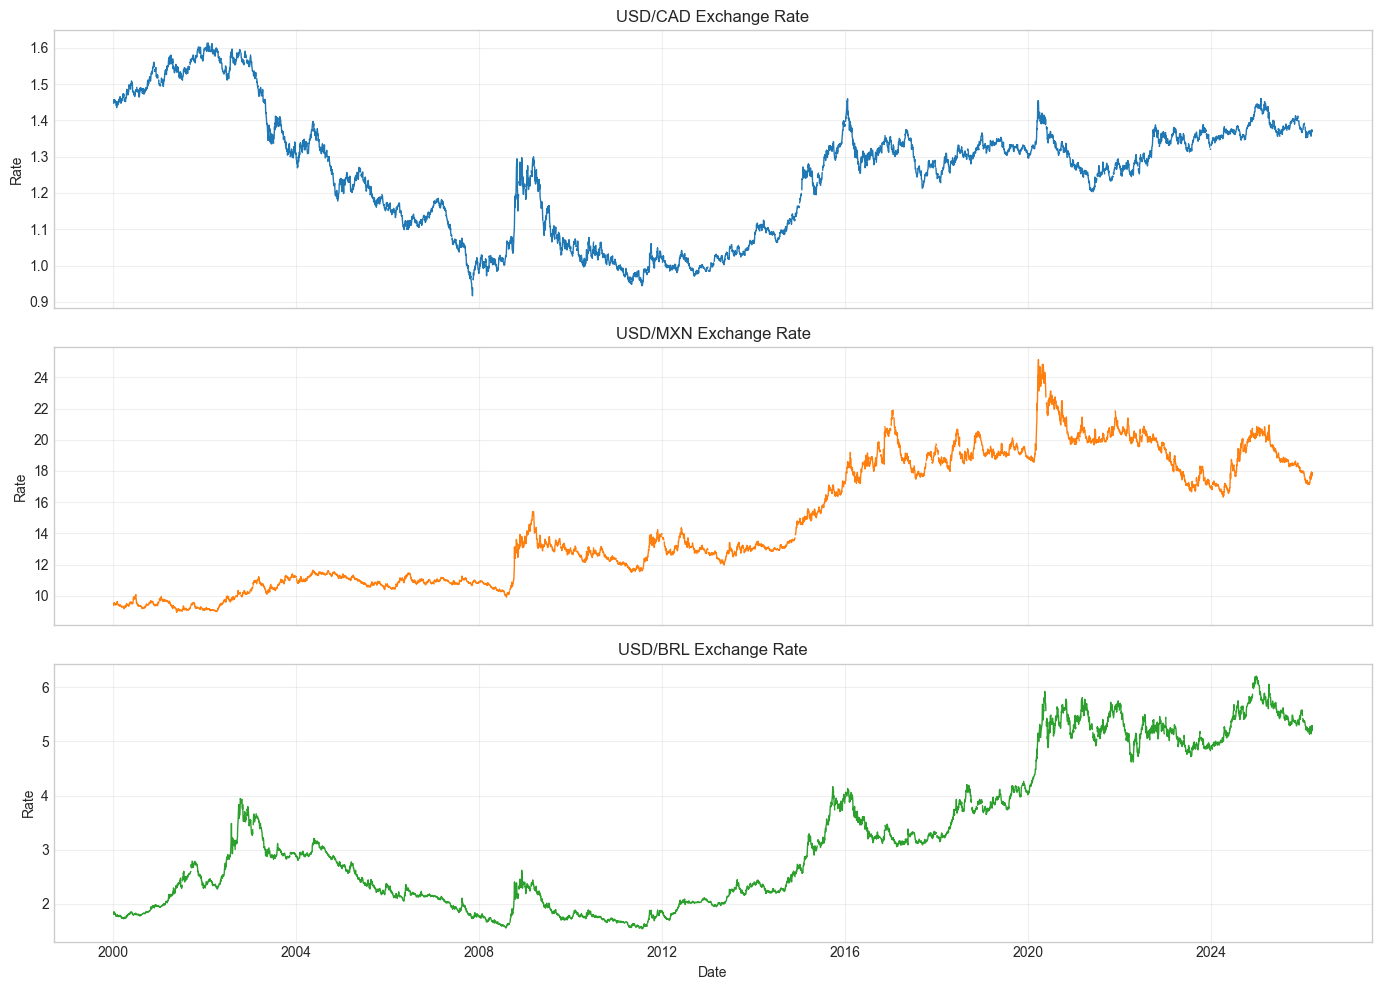

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_fx['DEXCAUS'], color='#1f77b4', lw=1)
axes[0].set_ylabel('Rate')
axes[0].set_title('USD/CAD Exchange Rate')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_fx['DEXMXUS'], color='#ff7f0e', lw=1)
axes[1].set_ylabel('Rate')
axes[1].set_title('USD/MXN Exchange Rate')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_fx['DEXBZUS'], color='#2ca02c', lw=1)
axes[2].set_ylabel('Rate')
axes[2].set_title('USD/BRL Exchange Rate')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{REPORTS}/01_exchange_rates_ts.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. REER Analysis

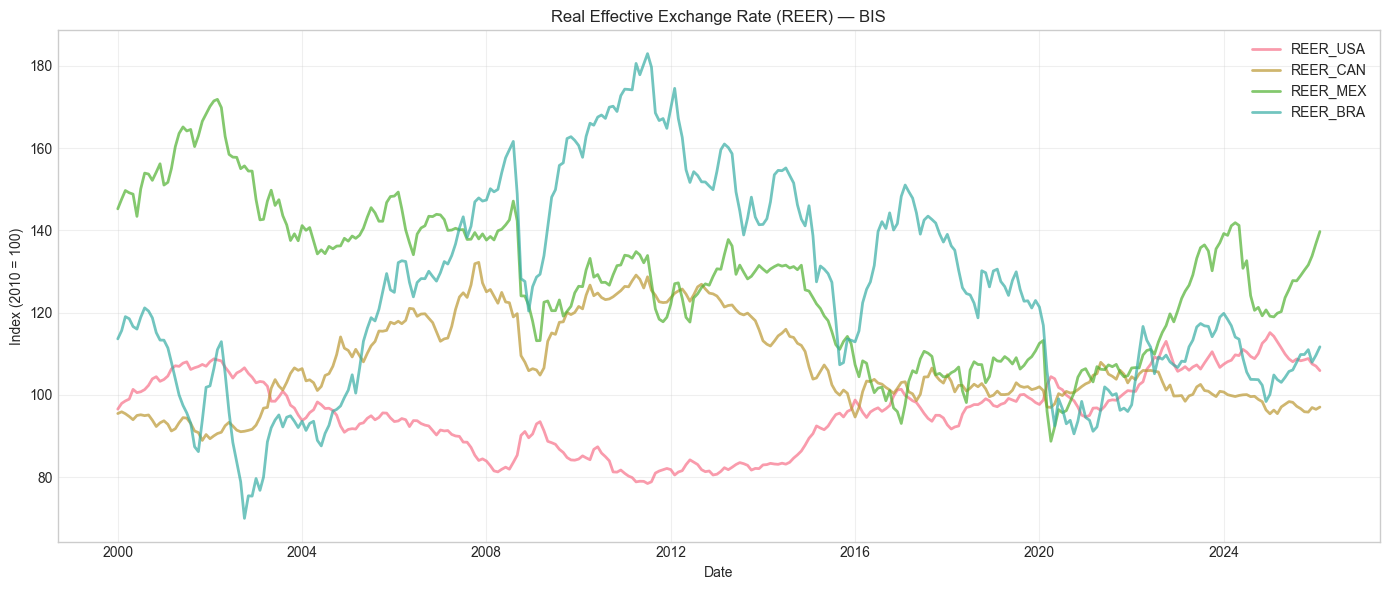

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
for col in df_reer.columns:
    ax.plot(df_reer.index, df_reer[col], label=col, lw=2, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Index (2010 = 100)')
ax.set_title('Real Effective Exchange Rate (REER) — BIS')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/02_reer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Trade Flows — Annual Totals

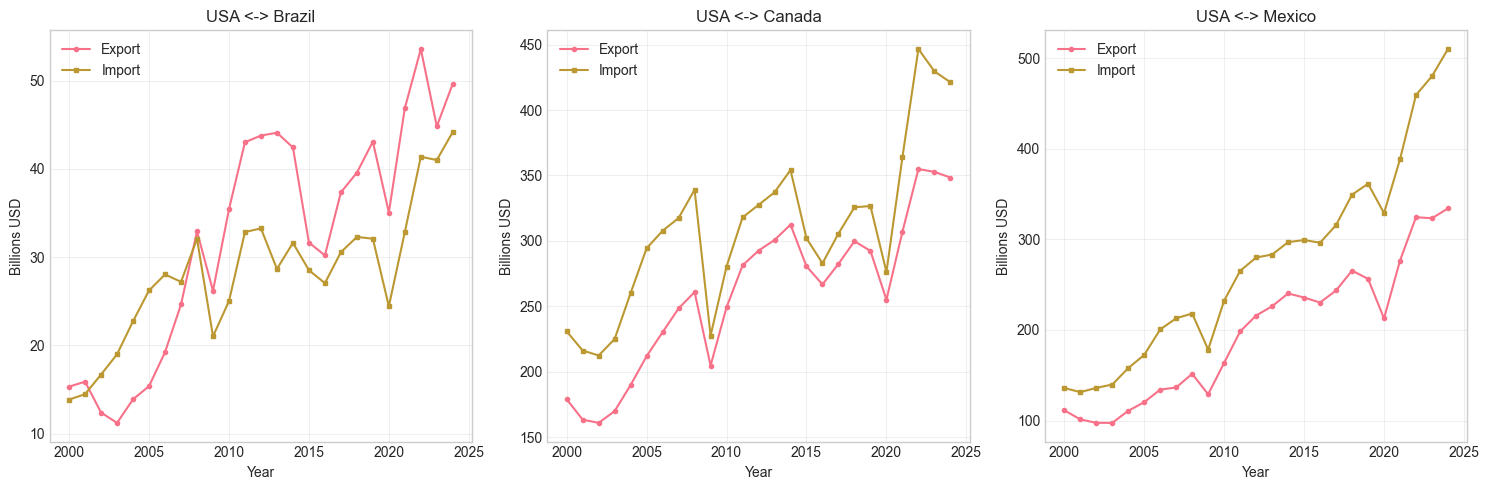

In [6]:
df_ct_pivot = df_ct_annual.pivot_table(
    index='period', columns=['partnerDesc', 'flowDesc'], values='primaryValue'
)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, partner in enumerate(['Brazil', 'Canada', 'Mexico']):
    ax = axes[i]
    try:
        ax.plot(df_ct_pivot[(partner, 'Export')].index, df_ct_pivot[(partner, 'Export')].values / 1e9, label='Export', marker='o', markersize=3)
        ax.plot(df_ct_pivot[(partner, 'Import')].index, df_ct_pivot[(partner, 'Import')].values / 1e9, label='Import', marker='s', markersize=3)
        ax.set_title(f'USA <-> {partner}')
        ax.set_xlabel('Year')
        ax.set_ylabel('Billions USD')
        ax.legend()
        ax.grid(True, alpha=0.3)
    except:
        pass
plt.tight_layout()
plt.savefig(f'{REPORTS}/03_trade_flows_annual.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Trade Flows — Monthly (2010-2024)

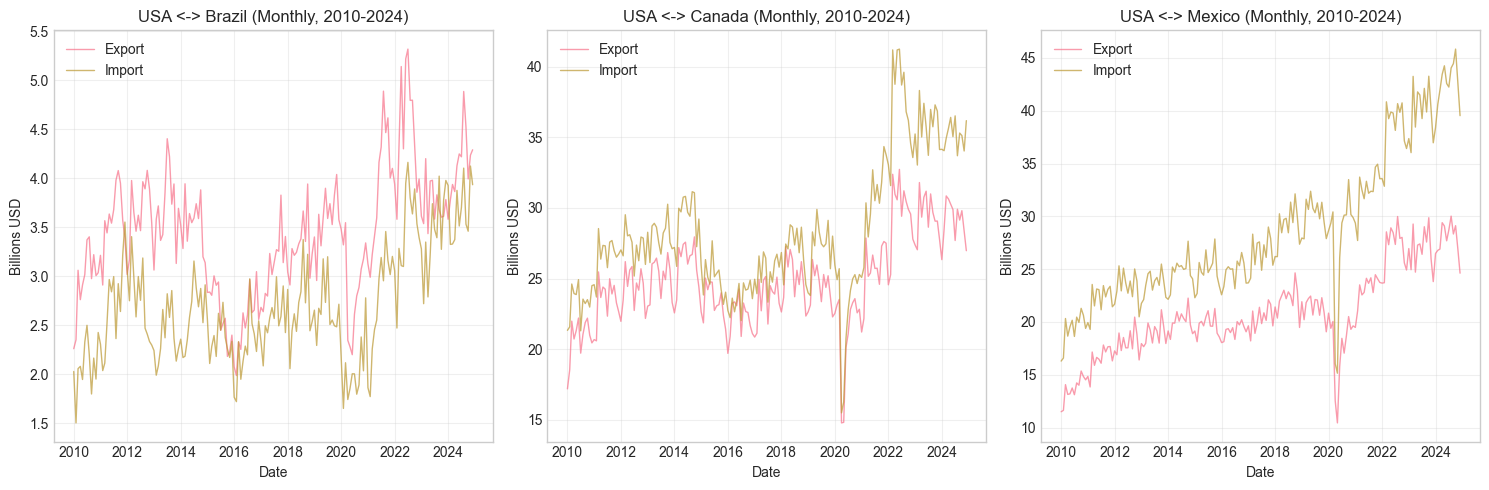

In [7]:
df_ct_monthly['date'] = pd.to_datetime(df_ct_monthly['period'].astype(str), format='%Y%m')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, partner in enumerate(['Brazil', 'Canada', 'Mexico']):
    ax = axes[i]
    for flow in ['Export', 'Import']:
        mask = (df_ct_monthly['partnerDesc'] == partner) & (df_ct_monthly['flowDesc'] == flow)
        subset = df_ct_monthly[mask].sort_values('date')
        ax.plot(subset['date'], subset['primaryValue'] / 1e9, label=flow, lw=1, alpha=0.7)
    ax.set_title(f'USA <-> {partner} (Monthly, 2010-2024)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Billions USD')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/04_trade_flows_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sectoral Analysis — Top HS2 Sectors

Top 10 HS2 Sectors by Trade Volume (2024):
  HS 87: 273.0B USD
  HS 84: 248.4B USD
  HS 27: 232.6B USD
  HS 85: 188.6B USD
  HS 99: 69.3B USD
  HS 39: 62.5B USD
  HS 90: 52.1B USD
  HS 88: 37.3B USD
  HS 73: 28.1B USD
  HS 72: 28.0B USD


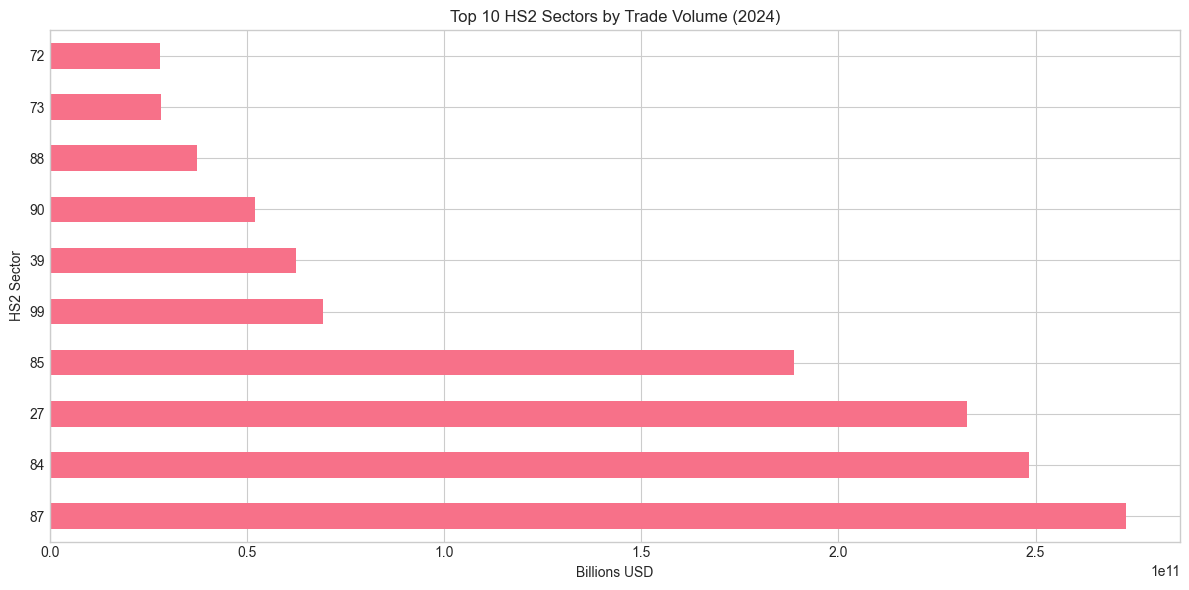

In [8]:
df_2024 = df_ct_hs2[df_ct_hs2['period'] == 2024]
top_sectors = df_2024.groupby('cmdCode')['primaryValue'].sum().nlargest(10)
print('Top 10 HS2 Sectors by Trade Volume (2024):')
for sector, value in top_sectors.items():
    print(f'  HS {sector}: {value/1e9:.1f}B USD')
fig, ax = plt.subplots(figsize=(12, 6))
top_sectors.plot(kind='barh', ax=ax)
ax.set_xlabel('Billions USD')
ax.set_ylabel('HS2 Sector')
ax.set_title('Top 10 HS2 Sectors by Trade Volume (2024)')
plt.tight_layout()
plt.savefig(f'{REPORTS}/05_top_sectors.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. World Bank — GDP per Capita (2000–2024)

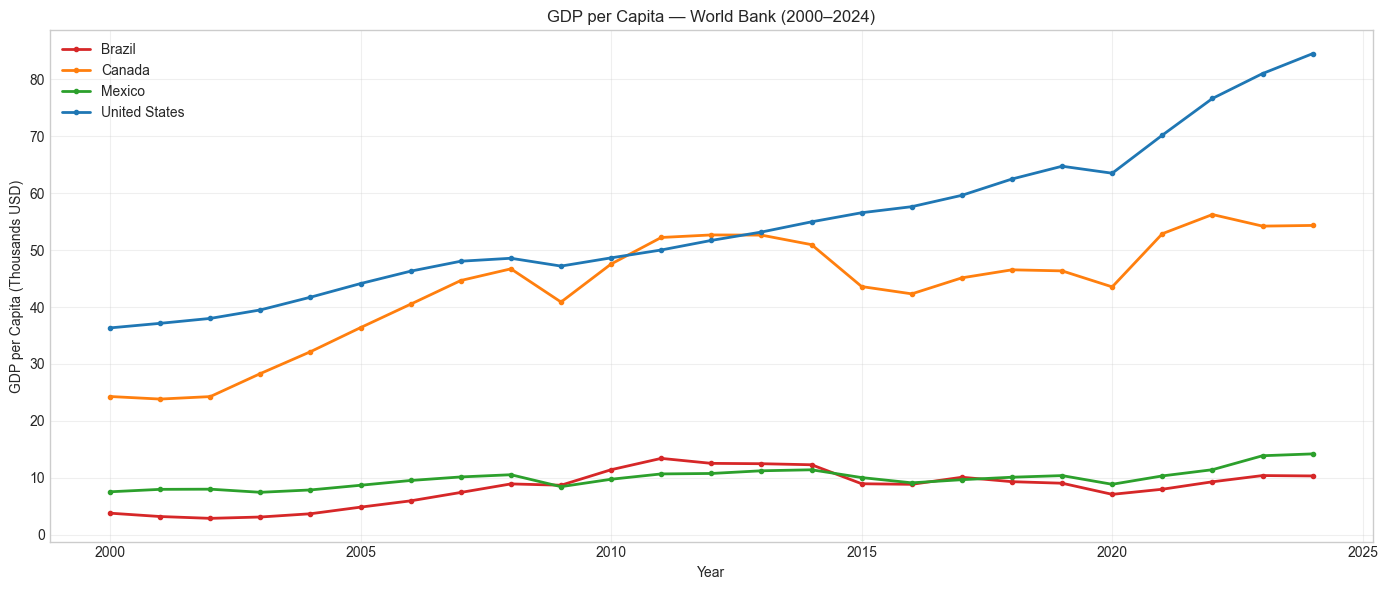

In [9]:
df_wb_clean = df_wb[df_wb['date'] <= 2024]
COLORS = {'United States': '#1f77b4', 'Canada': '#ff7f0e', 'Mexico': '#2ca02c', 'Brazil': '#d62728'}

fig, ax = plt.subplots(figsize=(14, 6))
for country in df_wb_clean['country'].unique():
    d = df_wb_clean[df_wb_clean['country'] == country].sort_values('date')
    ax.plot(d['date'], d['GDP_per_capita_USD'] / 1000, label=country,
            color=COLORS.get(country), lw=2, marker='o', markersize=3)
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita (Thousands USD)')
ax.set_title('GDP per Capita — World Bank (2000–2024)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/06_gdp_per_capita.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. World Bank — Population

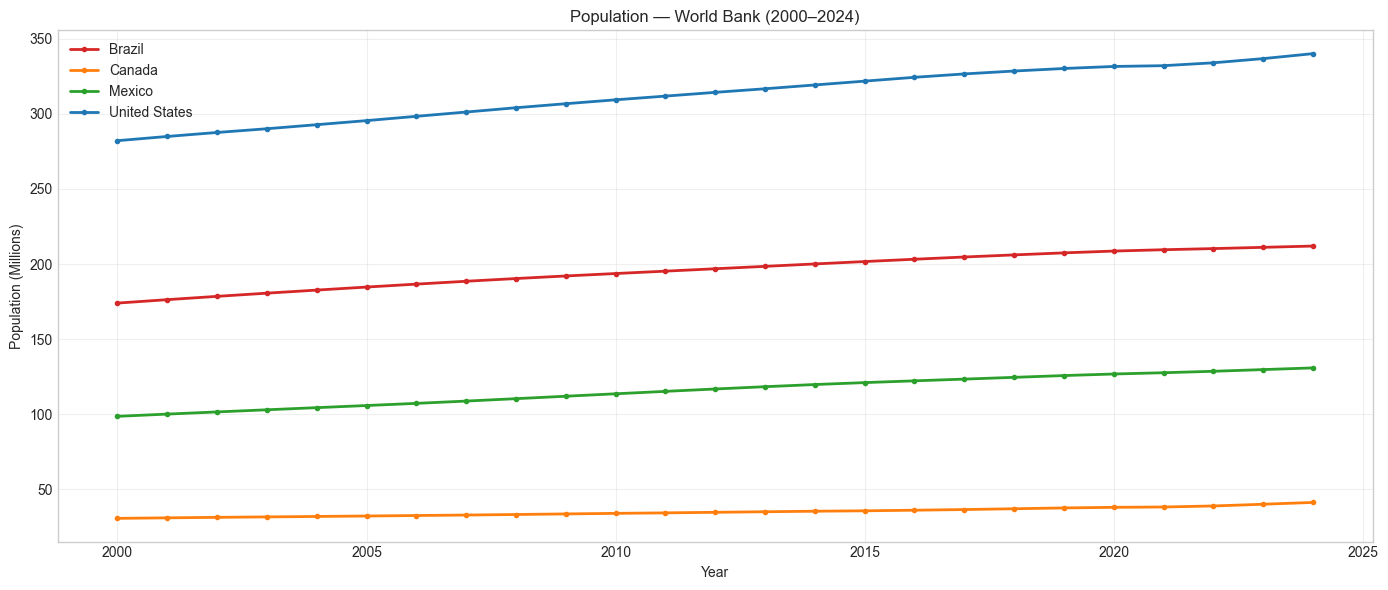

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
for country in df_wb_clean['country'].unique():
    d = df_wb_clean[df_wb_clean['country'] == country].sort_values('date')
    ax.plot(d['date'], d['Population'] / 1e6, label=country,
            color=COLORS.get(country), lw=2, marker='o', markersize=3)
ax.set_xlabel('Year')
ax.set_ylabel('Population (Millions)')
ax.set_title('Population — World Bank (2000–2024)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/07_population.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. World Bank — Inflation (CPI Annual %)

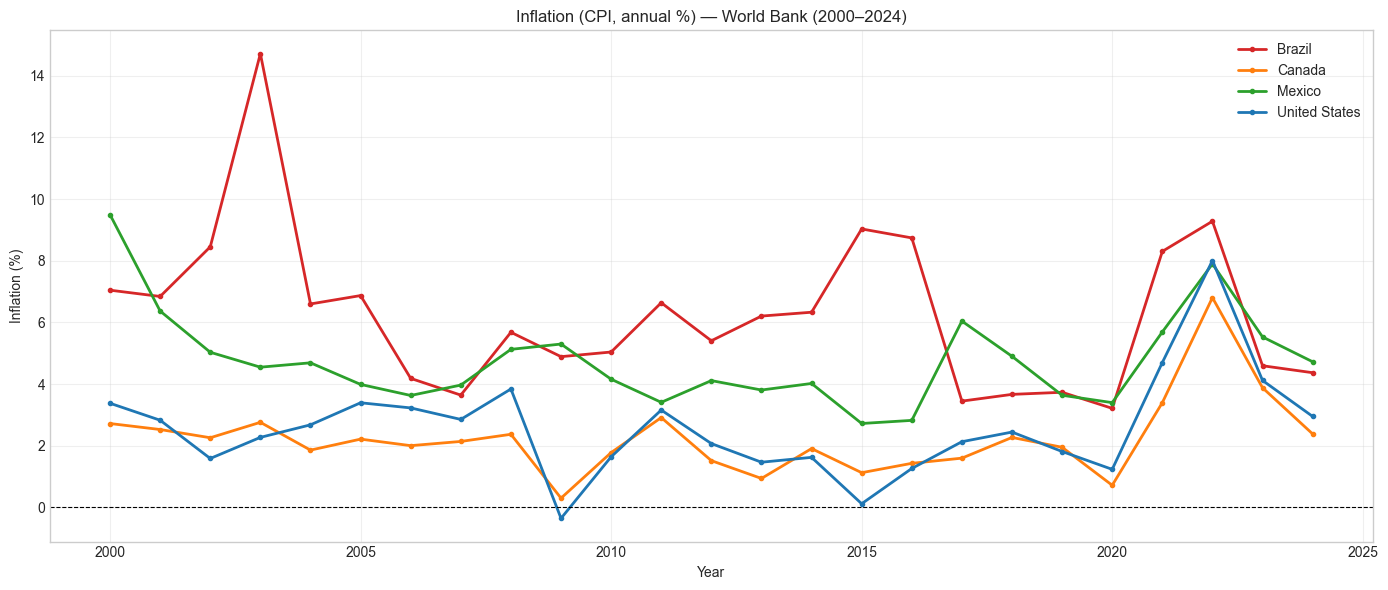

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
for country in df_wb_clean['country'].unique():
    d = df_wb_clean[df_wb_clean['country'] == country].sort_values('date')
    ax.plot(d['date'], d['Inflation_pct'], label=country,
            color=COLORS.get(country), lw=2, marker='o', markersize=3)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation (%)')
ax.set_title('Inflation (CPI, annual %) — World Bank (2000–2024)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/08_inflation_wb.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. World Bank — FDI Inflows

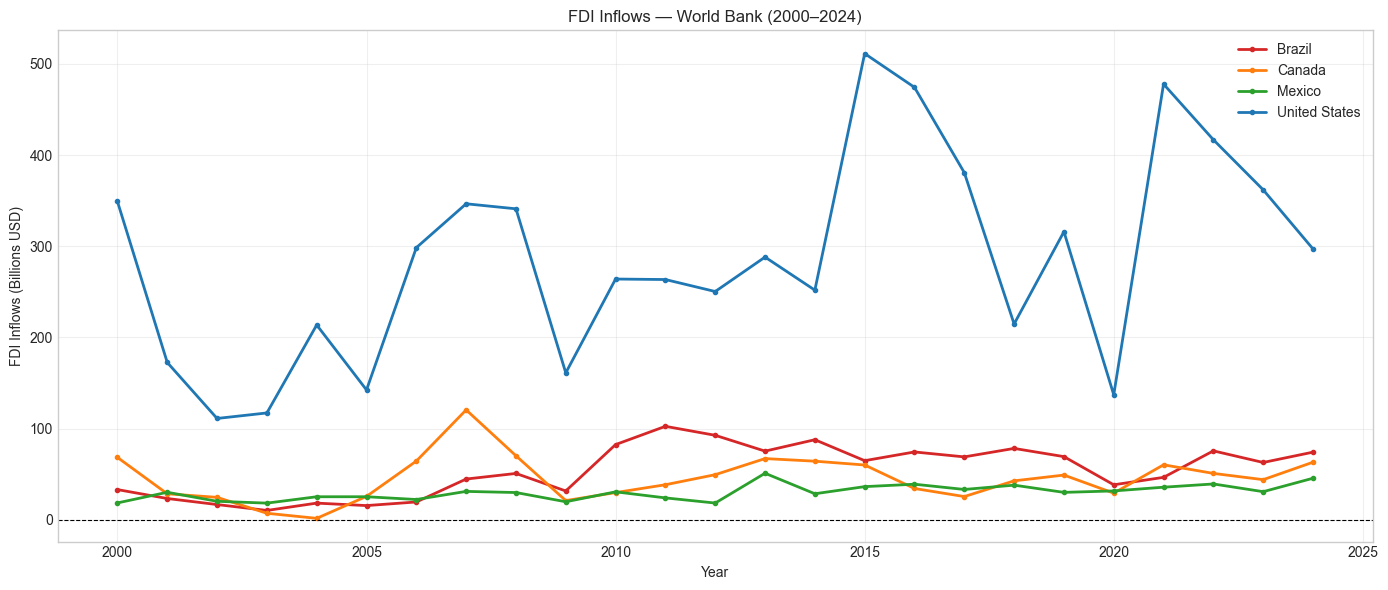

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
for country in df_wb_clean['country'].unique():
    d = df_wb_clean[df_wb_clean['country'] == country].sort_values('date')
    ax.plot(d['date'], d['FDI_inflows_USD'] / 1e9, label=country,
            color=COLORS.get(country), lw=2, marker='o', markersize=3)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Year')
ax.set_ylabel('FDI Inflows (Billions USD)')
ax.set_title('FDI Inflows — World Bank (2000–2024)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/09_fdi_inflows.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary Statistics — All Sources

In [13]:
print('=== EXCHANGE RATES ===')
print(df_fx.describe().round(4))

print('\n=== REER ===')
print(df_reer.describe().round(2))

print('\n=== MACRO USA ===')
print(df_macro_usa.describe().round(2))

print('\n=== WORLD BANK (2000-2024) ===')
wb_cols = [c for c in df_wb.columns if c not in ['country', 'date']]
print(df_wb_clean[wb_cols].describe().round(2))

=== EXCHANGE RATES ===
         DEXCAUS    DEXMXUS    DEXBZUS
count  6572.0000  6572.0000  6572.0000
mean      1.2555    14.6751     3.1936
std       0.1676     4.0189     1.3328
min       0.9168     8.9460     1.5375
25%       1.1065    10.9849     2.0478
50%       1.2845    13.1888     2.8653
75%       1.3594    18.7556     4.0708
max       1.6128    25.1320     6.2021

=== REER ===
       REER_USA  REER_CAN  REER_MEX  REER_BRA
count    314.00    314.00    314.00    314.00
mean      95.58    107.39    127.78    125.00
std        9.26     10.82     17.66     24.86
min       78.44     88.92     88.71     69.97
25%       88.07     99.94    112.25    105.28
50%       96.20    103.78    129.20    122.90
75%      102.80    117.48    139.99    143.40
max      115.12    132.20    171.83    182.94

=== MACRO USA ===
       FEDFUNDS  CPIAUCSL     GDPC1  UNRATE  INDPRO
count    314.00    313.00    104.00  313.00  314.00
mean       2.02    233.77  18272.71    5.64   97.27
std        2.03     41.

---

**Notes:**
- Exchange rates (daily) will be resampled to monthly in Data Preparation
- Comtrade monthly: 2010–2024 only (platform limitation)
- World Bank: 2000–2024 (2025 not yet published)
- Figures 01–09 saved to `reports/figures/`
- Next: `03_data_preparation.ipynb` — frequency alignment, outlier treatment, feature engineering

## 14. Sectoral Classification — Commodities vs. Manufactured vs. High-Tech

Classification based on OECD technology intensity and HS2 product categories,
as defined in TCC1 Section 2.3.2.

In [ ]:
# HS2 classification into three groups (OECD technology intensity)
# Reference: TCC1 Section 2.3.2
HS2_CATEGORIES = {
    'Commodities': [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
        25, 26, 27,
        41, 43, 44, 45, 46, 47,
        71, 72,
    ],
    'High-Tech': [
        30,   # pharmaceuticals
        84,   # machinery & computers
        85,   # electrical machinery & electronics
        88,   # aircraft & spacecraft
        90,   # optical, photographic, medical instruments
        91,   # clocks & watches
    ],
    'Manufactured Goods': [
        16, 17, 18, 19, 20, 21, 22, 23, 24,
        28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
        42, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59,
        60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83,
        86, 87, 89,
        92, 93, 94, 95, 96, 97,
    ],
}

hs_to_cat = {}
for cat, codes in HS2_CATEGORIES.items():
    for code in codes:
        hs_to_cat[code] = cat

print('HS2 classification built.')
for cat, codes in HS2_CATEGORIES.items():
    print(f'  {cat}: {len(codes)} HS2 chapters')


In [ ]:
df_hs2 = pd.read_csv(f'{DATA_RAW}/comtrade_annual_hs2.csv')
df_hs2 = df_hs2[df_hs2['cmdCode'] != 99].copy()
df_hs2['category'] = df_hs2['cmdCode'].map(hs_to_cat).fillna('Other')

df_cat = (
    df_hs2.groupby(['period', 'category'])['primaryValue']
    .sum()
    .reset_index()
    .pivot(index='period', columns='category', values='primaryValue')
    / 1e9
)

print('Trade by category (Billions USD):')
print(df_cat.tail(5).round(1))


In [ ]:
COLORS_CAT = {
    'Commodities':        '#d62728',
    'High-Tech':          '#1f77b4',
    'Manufactured Goods': '#ff7f0e',
    'Other':              '#aec7e8',
}
cats = ['Commodities', 'Manufactured Goods', 'High-Tech']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: stacked bar (evolution over time)
ax = axes[0]
bottom = None
for cat in cats:
    vals = df_cat.get(cat, pd.Series(0, index=df_cat.index))
    if bottom is None:
        ax.bar(df_cat.index, vals, label=cat, color=COLORS_CAT[cat], alpha=0.85)
        bottom = vals.copy()
    else:
        ax.bar(df_cat.index, vals, bottom=bottom, label=cat, color=COLORS_CAT[cat], alpha=0.85)
        bottom = bottom + vals
ax.set_xlabel('Year')
ax.set_ylabel('Trade Volume (Billions USD)')
ax.set_title('US Trade by Sector Category (2000-2024)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# Right: pie chart (2024 share)
ax2 = axes[1]
vals_2024 = df_cat.loc[2024, cats]
ax2.pie(
    vals_2024,
    labels=cats,
    colors=[COLORS_CAT[c] for c in cats],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
ax2.set_title('Sector Share of US Trade (2024)')

plt.tight_layout()
plt.savefig(f'{REPORTS}/12_sector_categories.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# High-Tech trade breakdown by partner country
df_ht = df_hs2[
    (df_hs2['category'] == 'High-Tech') &
    (df_hs2['partnerDesc'].isin(['Brazil', 'Canada', 'Mexico']))
].copy()

df_ht_pivot = (
    df_ht.groupby(['period', 'partnerDesc'])['primaryValue']
    .sum()
    .reset_index()
    .pivot(index='period', columns='partnerDesc', values='primaryValue')
    / 1e9
)

COLORS_PARTNERS = {'Brazil': '#2ca02c', 'Canada': '#1f77b4', 'Mexico': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(14, 6))
for partner in ['Canada', 'Mexico', 'Brazil']:
    if partner in df_ht_pivot.columns:
        ax.plot(
            df_ht_pivot.index, df_ht_pivot[partner],
            label=partner, color=COLORS_PARTNERS[partner],
            lw=2.5, marker='o', markersize=4
        )
ax.set_xlabel('Year')
ax.set_ylabel('Trade Volume (Billions USD)')
ax.set_title('US High-Tech Trade by Partner Country (2000-2024)\n(HS 30, 84, 85, 88, 90, 91)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/13_hightech_by_partner.png', dpi=150, bbox_inches='tight')
plt.show()

print('High-Tech trade in 2024 (Billions USD):')
if 2024 in df_ht_pivot.index:
    print(df_ht_pivot.loc[2024].round(1))
else:
    print(df_ht_pivot.tail(1).round(1))
